In [12]:
import math
import numpy as np
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [4]:
train_transform = transforms.Compose([
  transforms.RandomAffine(
      degrees=(-5, 5),
      translate=(0.1, 0.1),
      scale=(0.5, 1.0)),
  transforms.ToTensor()
])

train_dataset = dsets.MNIST(root ='./data',
                            train = True,
                            transform = train_transform,
                            download = True)

validation_dataset = dsets.MNIST(root ='./data',
                           train = False,
                           transform =transforms.ToTensor())

In [3]:
print("number of training samples: " + str(len(train_dataset)) + "\n" +
      "number of validation samples: " + str(len(validation_dataset)))

number of training samples: 60000
number of validation samples: 10000


In [ ]:
print( (train_dataset[0][1]))

print("size of the 1st training sample: ", train_dataset[0][0].size())

5
size of the 1st training sample:  torch.Size([1, 28, 28])


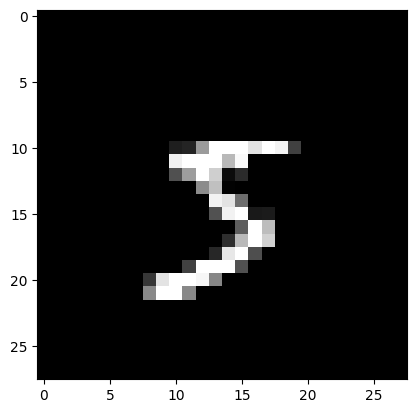

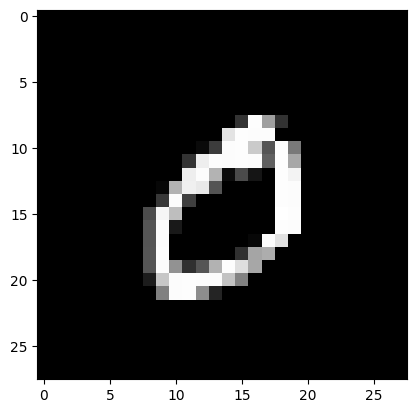

In [11]:
img_5 = train_dataset[0][0].numpy().reshape(28, 28)
plt.imshow(img_5, cmap='gray')
plt.show()
img_0 = train_dataset[1][0].numpy().reshape(28, 28)
plt.imshow(img_0, cmap='gray')
plt.show()

In [12]:
batach_size = 256
train_loader = DataLoader(dataset=train_dataset,
                                batch_size=batach_size,
                                shuffle=True)
val_loader = DataLoader(dataset=validation_dataset,
                            batch_size=batach_size,
                            shuffle=False)

In [13]:
class SimpleNeuralNet(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(SimpleNeuralNet,self).__init__()

        self.layer1=nn.Linear(n_inputs,256)
        self.layer2=nn.Linear(256,256)
        self.layer3=nn.Linear(256,n_outputs)
        self.activation=nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)


    def forward(self,x):

        x=self.layer1(x)
        x=self.activation(x)
        x = self.dropout(x)
        x=self.layer2(x)
        x=self.activation(x)
        x = self.dropout(x)
        x=self.layer3(x)
        return x



In [14]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet,self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3,3), stride=1, padding=1)
        #shape: 32*28*28
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        #shape: 32*14*14

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1)
        #shape: 32*14*14
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        #shape: 32*7*7

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(1568, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)


    def forward(self,x):

        x=self.conv1(x)
        x=self.act1(x)
        x=self.drop1(x)
        x = self.pool1(x)
        x=self.conv2(x)
        x=self.act2(x)
        x = self.pool2(x)
        x=self.flat(x)
        x=self.fc3(x)
        x=self.act3(x)
        x=self.drop3(x)

        x=self.fc4(x)
        return x



In [15]:
#there are already two pretrained models under /models for both types.

n_inputs = 28*28
n_outputs = 10
model_simpleNet = SimpleNeuralNet(n_inputs, n_outputs)
model_simpleNet.to(device)

model_conv2=ConvNet()
model_conv2.to(device)

#in order to load a pretrianed cnn_model uncomment this section:
state_dict = torch.load("models/mnist_conv2.pth", weights_only=True,map_location=torch.device(device))
model_conv2=ConvNet()
model_conv2.load_state_dict(state_dict)


#in order to load a pretrained simpleNet_model uncomment this section:
#state_dict = torch.load("models/mnist_simpeNet.pth", weights_only=True,map_location=torch.device(device))
#model_simpleNet=SimpleNeuralNet(n_inputs, n_outputs)
#model_simpleNet.load_state_dict(state_dict)


<All keys matched successfully>

In [17]:
learning_rate=0.001
optimizer_model_simpleNet=torch.optim.Adam(model_simpleNet.parameters(),learning_rate)
optimizer_conv2=torch.optim.Adam(model_conv2.parameters(),learning_rate)
criterion = nn.CrossEntropyLoss()

In [ ]:
acc_log=[]
train_loss_log=[]
val_loss_log=[]

Epoch: 0, Validation Loss= 27.7913 x10^-2, Training Loss= 121.0512 x10^-2, Accuracy= 92.58 
Epoch: 1, Validation Loss= 19.3240 x10^-2, Training Loss= 57.8422 x10^-2, Accuracy= 94.64 
Epoch: 2, Validation Loss= 13.8061 x10^-2, Training Loss= 44.9557 x10^-2, Accuracy= 95.79 
Epoch: 3, Validation Loss= 12.6755 x10^-2, Training Loss= 38.1769 x10^-2, Accuracy= 96.29 
Epoch: 4, Validation Loss= 10.9897 x10^-2, Training Loss= 34.4983 x10^-2, Accuracy= 96.64 
Epoch: 5, Validation Loss= 9.2812 x10^-2, Training Loss= 31.5400 x10^-2, Accuracy= 97.05 
Epoch: 6, Validation Loss= 9.1713 x10^-2, Training Loss= 29.3999 x10^-2, Accuracy= 97.05 
Epoch: 7, Validation Loss= 7.9704 x10^-2, Training Loss= 27.3230 x10^-2, Accuracy= 97.28 
Epoch: 8, Validation Loss= 7.4153 x10^-2, Training Loss= 26.3719 x10^-2, Accuracy= 97.44 
Epoch: 9, Validation Loss= 7.1711 x10^-2, Training Loss= 25.1971 x10^-2, Accuracy= 97.78 
Epoch: 10, Validation Loss= 6.7411 x10^-2, Training Loss= 24.4035 x10^-2, Accuracy= 97.79 
Epo

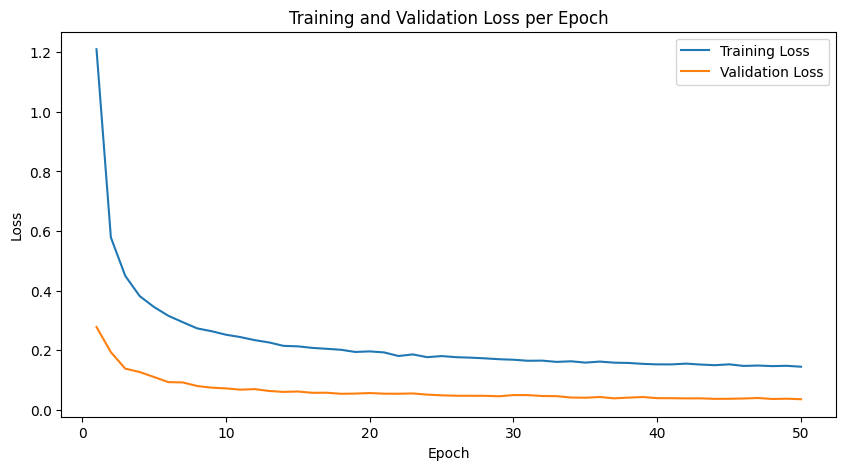

In [ ]:
#SimpleneuralNetwork Training
epochs=50

for epoch in range(epochs):
  train_epoch_loss=0
  model_simpleNet.train()
  for  (images,labels) in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer_model_simpleNet.zero_grad()
    outputs=model_simpleNet(images.view(-1,28*28))
    loss = criterion(outputs, labels)
    train_epoch_loss += loss.item()
    loss.backward()
    optimizer_model_simpleNet.step()

  train_loss_log.append(train_epoch_loss/len(train_loader))
  correct=0
  val_epoch_loss=0

  model_simpleNet.eval()
  with torch.no_grad():
      for images , labels in val_loader :
          images=images.to(device)
          labels=labels.to(device)
          outputs=model_simpleNet(images.view(-1,28*28))
          loss = criterion(outputs, labels)
          val_epoch_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          correct+= (predicted==labels).sum()

      accuracy=100 * (correct.item()) / len(validation_dataset)
      acc_log.append(accuracy)
      val_loss_log.append(val_epoch_loss / len(val_loader))
      print(f"Epoch: {epoch}, Validation Loss= {val_epoch_loss / len(val_loader)*100:.4f} x10^-2, Training Loss= {train_epoch_loss/len(train_loader)*100:.4f} x10^-2, Accuracy= {accuracy} ")
#to save your model uncomment both these lines and add its name
#torch.save(model_simpleNet.state_dict(), 'mnist_simpeNet_"ENTER_MODEL_NAME"".pth')
#print("Model weights saved successfully.")

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+ 1), train_loss_log, label='Training Loss')
plt.plot(range(1, epochs + 1), val_loss_log, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

In [ ]:
acc_log=[]
train_loss_log=[]
val_loss_log=[]

Epoch: 0, Validation Loss= 15.1842 x10^-2, Training Loss= 86.4570 x10^-2, Accuracy= 95.82 
Epoch: 1, Validation Loss= 9.4005 x10^-2, Training Loss= 30.3312 x10^-2, Accuracy= 97.49 
Epoch: 2, Validation Loss= 8.6284 x10^-2, Training Loss= 22.9696 x10^-2, Accuracy= 97.57 
Epoch: 3, Validation Loss= 7.7072 x10^-2, Training Loss= 19.1976 x10^-2, Accuracy= 97.77 
Epoch: 4, Validation Loss= 7.2650 x10^-2, Training Loss= 17.6533 x10^-2, Accuracy= 97.83 
Epoch: 5, Validation Loss= 5.4594 x10^-2, Training Loss= 15.9118 x10^-2, Accuracy= 98.68 
Epoch: 6, Validation Loss= 5.4942 x10^-2, Training Loss= 14.8541 x10^-2, Accuracy= 98.67 
Epoch: 7, Validation Loss= 4.0634 x10^-2, Training Loss= 13.7934 x10^-2, Accuracy= 98.92 
Epoch: 8, Validation Loss= 4.1910 x10^-2, Training Loss= 12.5007 x10^-2, Accuracy= 98.93 
Epoch: 9, Validation Loss= 3.9222 x10^-2, Training Loss= 12.0784 x10^-2, Accuracy= 98.89 
Epoch: 10, Validation Loss= 3.5622 x10^-2, Training Loss= 11.5193 x10^-2, Accuracy= 99.06 
Epoch: 1

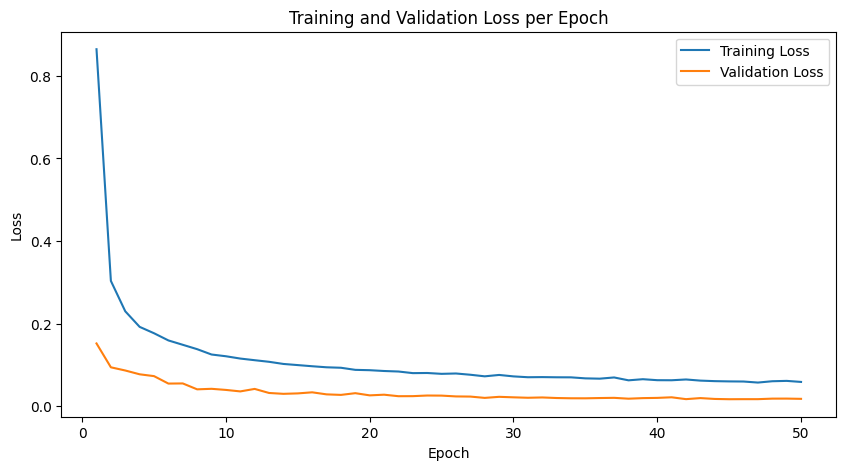

In [ ]:
#conv2 Training
epochs=50


for epoch in range(epochs):
  train_epoch_loss=0
  model_conv2.train()
  for  (images,labels) in train_loader:
    images=images.to(device)
    labels=labels.to(device)
    optimizer_conv2.zero_grad()
    outputs=model_conv2(images.view(-1,1,28,28))
    loss = criterion(outputs, labels)
    train_epoch_loss += loss.item()
    loss.backward()
    optimizer_conv2.step()

  train_loss_log.append(train_epoch_loss/len(train_loader))
  correct=0
  val_epoch_loss=0

  model_conv2.eval()
  with torch.no_grad():
      for images , labels in val_loader :
          images=images.to(device)
          labels=labels.to(device)
          outputs=model_conv2(images.view(-1,1,28,28))
          loss = criterion(outputs, labels)
          val_epoch_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          correct+= (predicted==labels).sum()

      accuracy=100 * (correct.item()) / len(validation_dataset)
      acc_log.append(accuracy)
      val_loss_log.append(val_epoch_loss / len(val_loader))
      print(f"Epoch: {epoch}, Validation Loss= {val_epoch_loss / len(val_loader)*100:.4f} x10^-2, Training Loss= {train_epoch_loss/len(train_loader)*100:.4f} x10^-2, Accuracy= {accuracy} ")

torch.save(model_conv2.state_dict(), 'mnist_conv2.pth')
print("Model weights saved successfully.")

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+ 1), train_loss_log, label='Training Loss')
plt.plot(range(1, epochs + 1), val_loss_log, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

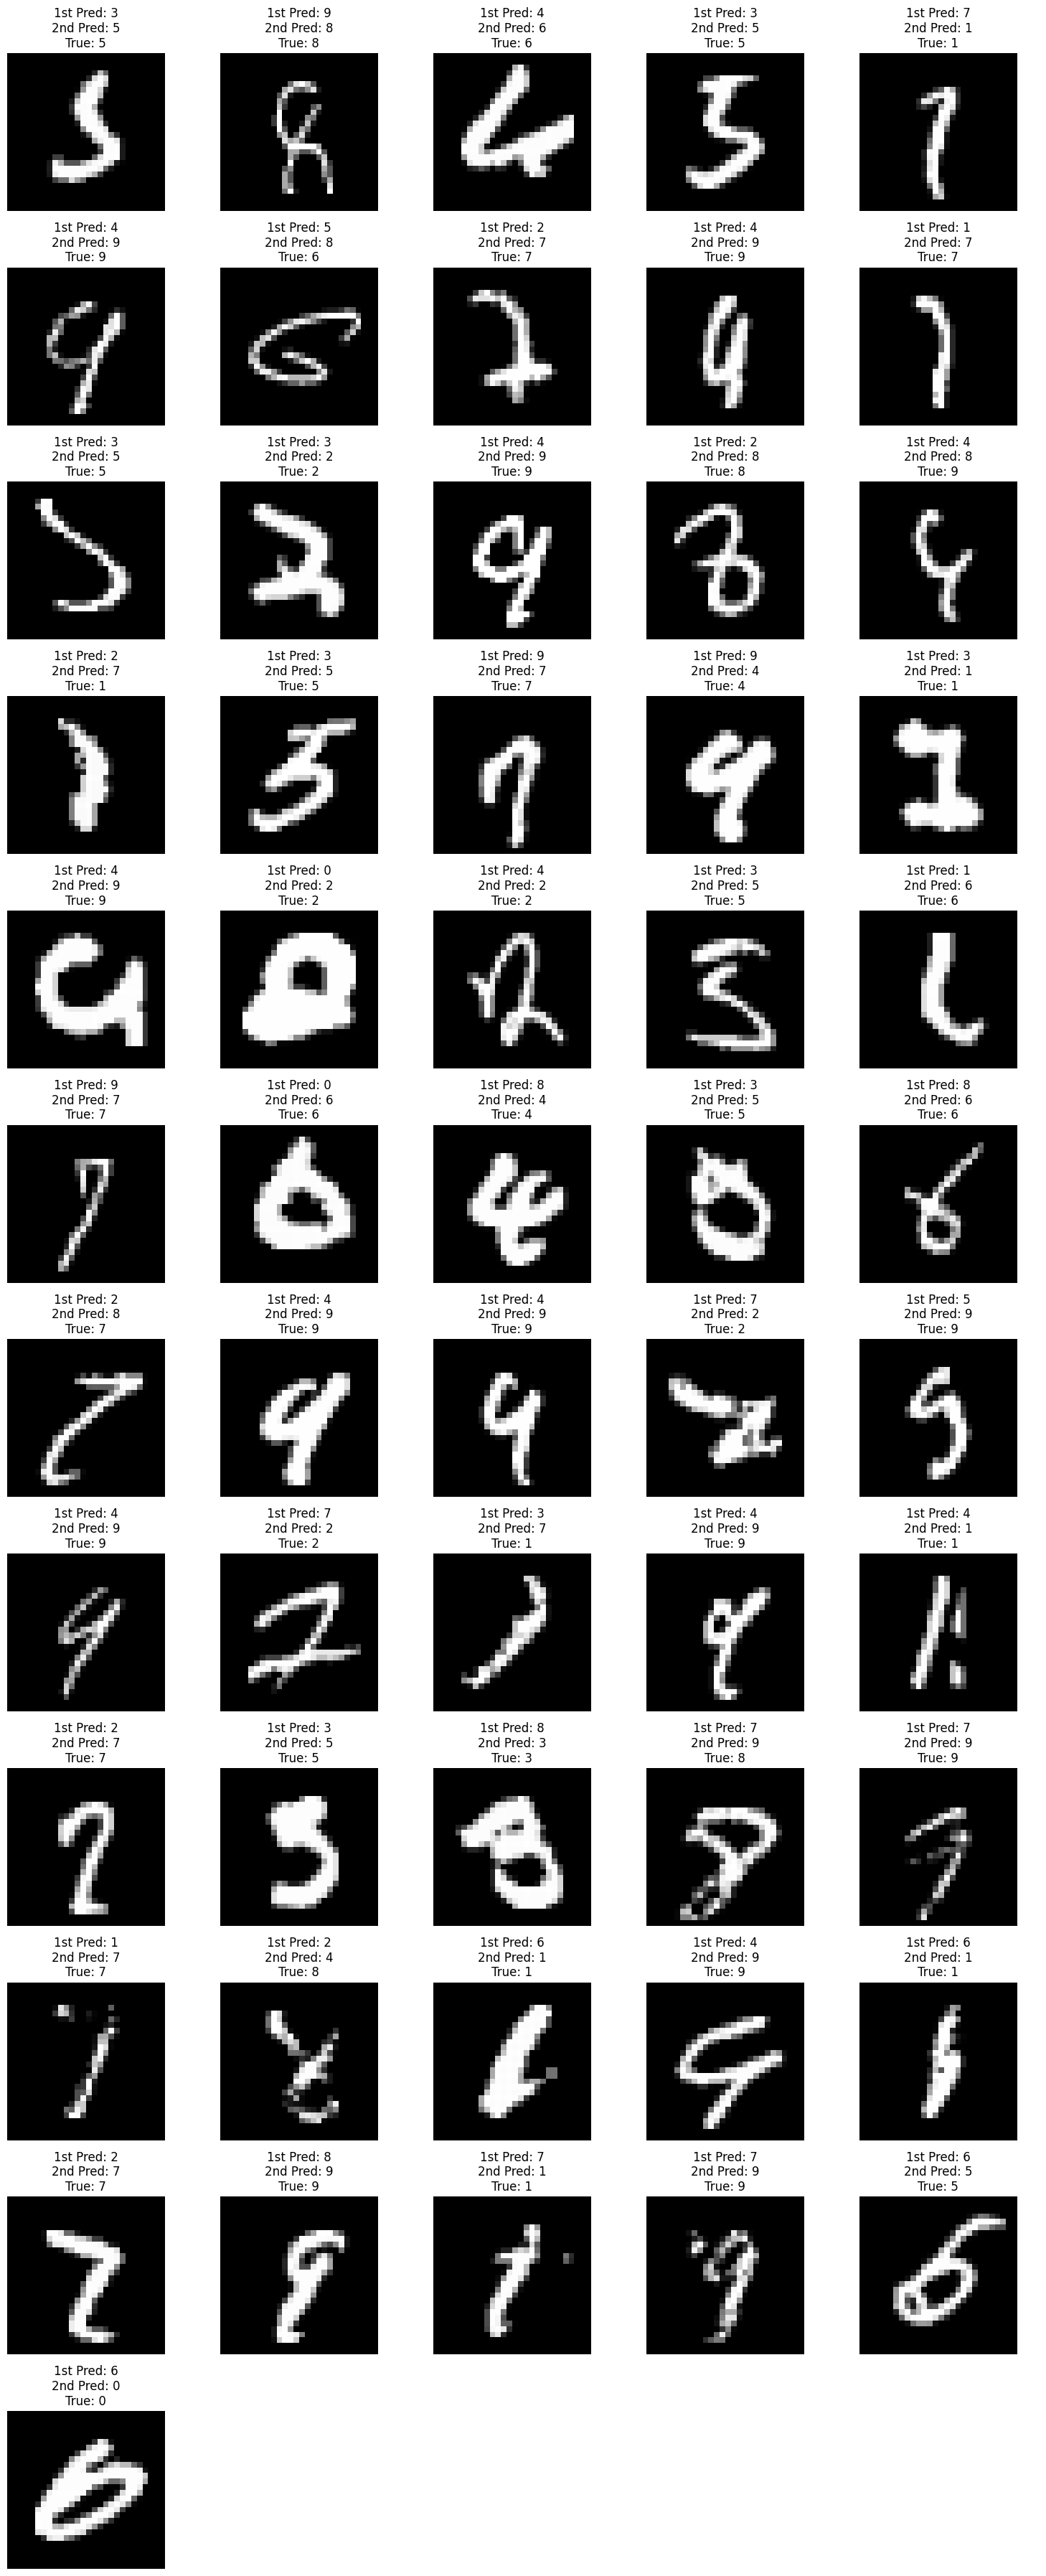

In [18]:

model_conv2.eval()
misclassified_images = []
model_predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_conv2(images.view(-1, 1, 28, 28))
        _, top_indices = torch.topk(outputs, 2, dim=1)
        predicted = top_indices[:, 0]
        second_best = top_indices[:, 1]
        wrong_indices = (predicted != labels).nonzero(as_tuple=True)[0]

        for idx in wrong_indices:
            img_numpy = images[idx].cpu().numpy().reshape(28, 28)
            misclassified_images.append(img_numpy)
            model_predictions.append((predicted[idx].item(), second_best[idx].item()))
            true_labels.append(labels[idx].item())


cols = 5
rows = math.ceil(len(misclassified_images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes_flat = axes.flatten()

for i in range(len(misclassified_images)):
    pred1, pred2 = model_predictions[i]
    axes_flat[i].imshow(misclassified_images[i], cmap='gray')
    axes_flat[i].set_title(f"1st Pred: {pred1}\n2nd Pred: {pred2}\nTrue: {true_labels[i]}")
    axes_flat[i].axis('off')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

In [16]:
#UI generated by Claud' Sonnet 4.6

import tkinter as tk
from PIL import Image, ImageDraw
matplotlib.use("TkAgg")
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.gridspec as gridspec

#these are updatable parameters to tincker around with!

ROWS       = 6   # how many feature-map channels to show per layer column
UPDATE_MS  = 50   # ms between live inference calls (lower = more responsive but heavier)
BRUSH_R    = 10    # drawing brush radius in pixels
FIG_SCALE  = 2.5   # scale the matplotlib panel (1.0 = default, 2.0 = double size)

class DrawDigitApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Live CNN Visualization")

        main = tk.Frame(root)
        main.pack(padx=10, pady=10)

        # ── Left: drawing canvas ───────────────────────────────────────────────
        left = tk.Frame(main)
        left.pack(side=tk.LEFT, padx=(0, 12))

        self.image = Image.new("RGB", (280, 280), "black")
        self.draw  = ImageDraw.Draw(self.image)

        self.canvas = tk.Canvas(left, width=280, height=280, bg="black",
                                highlightthickness=1, highlightbackground="#555")
        self.canvas.pack()
        self.canvas.bind("<B1-Motion>", self.live_update)

        tk.Button(left, text="Clear", command=self.clear_canvas,
                  width=12).pack(pady=6)

        self.pred_label = tk.Label(left, text="", font=("Helvetica", 18, "bold"))
        self.pred_label.pack()

        # ── Right: embedded matplotlib figure ─────────────────────────────────
        # Columns: Input | Conv1 | Pool1 | Conv2 | Pool2 | Output(bar)
        # Input spans the middle half of ROWS; all others show ROWS channels.
        fig_h = max(4.0, ROWS * 0.75) * FIG_SCALE
        self.fig = Figure(figsize=(13 * FIG_SCALE, fig_h), tight_layout=False)

        gs = gridspec.GridSpec(
            ROWS, 6,
            figure=self.fig,
            left=0.02, right=0.98,
            top=1 - 0.7 / fig_h,   # leave room for column titles
            bottom=0.04,
            wspace=0.05, hspace=0.05
        )

        col_labels = ["Input", "Conv 1", "Pool 1", "Conv 2", "Pool 2", "Output"]
        self.im_plots = {}   # (col, row) → AxesImage

        # Input: single map centred vertically
        mid = ROWS // 2
        r0, r1 = max(0, mid - 1), min(ROWS, mid + 1)
        ax_in = self.fig.add_subplot(gs[r0:r1, 0])
        ax_in.set_xticks([]); ax_in.set_yticks([])
        ax_in.set_title(col_labels[0], fontsize=9, pad=4)
        im_in = ax_in.imshow(np.zeros((28, 28)), cmap="gray",
                             vmin=0, vmax=1, aspect="equal",
                             interpolation="nearest")
        self.im_plots[(0, 0)] = im_in

        # Feature-map columns 1–4
        for c in range(1, 5):
            for r in range(ROWS):
                ax = self.fig.add_subplot(gs[r, c])
                ax.set_xticks([]); ax.set_yticks([])
                if r == 0:
                    ax.set_title(col_labels[c], fontsize=9, pad=4)
                im = ax.imshow(np.zeros((14, 14)), cmap="magma",
                               aspect="equal", interpolation="nearest")
                self.im_plots[(c, r)] = im

        # Output bar chart
        self.bar_ax = self.fig.add_subplot(gs[:, 5])
        self.bar_ax.set_title("Output", fontsize=9, pad=4)
        self.bar_ax.set_xlim(0, 1)
        self.bar_ax.set_ylim(-0.5, 9.5)
        self.bar_ax.set_yticks(range(10))
        self.bar_ax.set_yticklabels([str(i) for i in range(10)], fontsize=8)
        self.bar_ax.set_xticks([])
        self.bar_ax.invert_yaxis()
        self.bars = self.bar_ax.barh(range(10), np.zeros(10),
                                     height=0.7, color="steelblue", align="center")

        self.plot_canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.plot_canvas.get_tk_widget().pack(side=tk.LEFT)
        self.plot_canvas.draw()

        self.is_predicting = False

    def run_inference_and_update_plot(self):
        gray    = self.image.convert("L")
        resized = gray.resize((28, 28), Image.Resampling.BILINEAR)
        tensor  = transforms.ToTensor()(resized).view(-1, 1, 28, 28)

        model_conv2.eval()
        with torch.no_grad():
            c1  = model_conv2.conv1(tensor)
            p1  = model_conv2.pool1(model_conv2.act1(c1))
            c2  = model_conv2.conv2(p1)
            p2  = model_conv2.pool2(model_conv2.act2(c2))
            a3  = model_conv2.act3(model_conv2.fc3(model_conv2.flat(p2)))
            out = model_conv2.fc4(a3)

        probs = torch.softmax(out, dim=1)[0].cpu().numpy()
        pred  = int(probs.argmax())

        layers_data = [tensor[0], c1[0], p1[0], c2[0], p2[0]]

        # Update input
        np_d = layers_data[0][0].cpu().numpy()
        im   = self.im_plots[(0, 0)]
        im.set_data(np_d)
        im.set_clim(np_d.min(), max(np_d.max(), np_d.min() + 1e-5))

        # Update feature-map columns
        for c in range(1, 5):
            data = layers_data[c]
            n_ch = data.shape[0]
            for r in range(ROWS):
                np_d = data[r % n_ch].cpu().numpy()
                im   = self.im_plots[(c, r)]
                im.set_data(np_d)
                im.set_clim(np_d.min(), max(np_d.max(), np_d.min() + 1e-5))

        # Update bar chart
        for i, (bar, p) in enumerate(zip(self.bars, probs)):
            bar.set_width(float(p))
            bar.set_color("#e07b39" if i == pred else "steelblue")

        self.pred_label.config(
            text=f"Prediction: {pred}   ({probs[pred]*100:.1f}%)"
        )
        self.plot_canvas.draw_idle()
        self.is_predicting = False

    # ── Drawing ────────────────────────────────────────────────────────────────
    def live_update(self, event):
        x1, y1 = event.x - BRUSH_R, event.y - BRUSH_R
        x2, y2 = event.x + BRUSH_R, event.y + BRUSH_R
        self.canvas.create_oval(x1, y1, x2, y2, fill="white", outline="white")
        self.draw.ellipse([x1, y1, x2, y2], fill="white")

        if not self.is_predicting:
            self.is_predicting = True
            self.root.after(UPDATE_MS, self.run_inference_and_update_plot)

    def clear_canvas(self):
        self.canvas.delete("all")
        self.image = Image.new("RGB", (280, 280), "black")
        self.draw  = ImageDraw.Draw(self.image)

        self.im_plots[(0, 0)].set_data(np.zeros((28, 28)))
        for c in range(1, 5):
            for r in range(ROWS):
                self.im_plots[(c, r)].set_data(np.zeros((14, 14)))
        for bar in self.bars:
            bar.set_width(0)

        self.pred_label.config(text="")
        self.plot_canvas.draw_idle()


if __name__ == "__main__":
    root = tk.Tk()
    app  = DrawDigitApp(root)
    root.mainloop()

/tmp/ipykernel_118892/2077720964.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.plot_canvas.draw()
/home/fourat-zai-el-amri/miniconda3/envs/ai_agent/lib/python3.11/tkinter/__init__.py:861: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args)
